# Análisis Exploratorio de Datos (EDA): Himalayan Climbing Expeditions

Este cuaderno realiza una exploración profunda del dataset **Himalayan Climbing Expeditions (Individual Members)**, obtenido de TidyTuesday (septiembre 2020), basado en la base de datos de Elizabeth Hawley.

**Objetivo:** Identificar patrones, tendencias y factores clave relacionados con el éxito de los escaladores y la seguridad en la montaña.

### Diccionario de Datos

| Categoría | Variable | Descripción |
| :--- | :--- | :--- |
| **Identificadores** | `expedition_id`, `member_id`, `peak_id` | Claves para identificar expediciones, miembros y montañas. |
| **Escalador** | `age`, `sex`, `citizenship`, `expedition_role`, `hired` | Características personales y rol (miembro vs contratado). |
| **Contexto** | `year`, `season`, `solo`, `oxygen_used` | Entorno y logística de la escalada. |
| **Resultados** | `success`, `highpoint_metres` | Variable objetivo (éxito) y altura máxima alcanzada. |
| **Riesgo** | `died`, `death_cause`, `injured`, `injury_type` | Información sobre fallecimientos y lesiones. |

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style="darkgrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Librerías cargadas satisfactoriamente.")

Librerías cargadas satisfactoriamente.


In [14]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-09-22/members.csv"
df = pd.read_csv(url)

print(f"Dataset cargado con {df.shape[0]} registros y {df.shape[1]} columnas.")
df.head()

Dataset cargado con 76519 registros y 21 columnas.


,expedition_id,member_id,peak_id,peak_name,year,season,sex,age,citizenship,expedition_role,...,highpoint_metres,success,solo,oxygen_used,died,death_cause,death_height_metres,injured,injury_type,injury_height_metres
0,AMAD78301,AMAD78301-01,AMAD,Ama Dablam,1978,Autumn,M,40.0,France,Leader,...,NaN,False,False,False,False,NaN,NaN,False,NaN,NaN
1,AMAD78301,AMAD78301-02,AMAD,Ama Dablam,1978,Autumn,M,41.0,France,Deputy Leader,...,6000.0,False,False,False,False,NaN,NaN,False,NaN,NaN
2,AMAD78301,AMAD78301-03,AMAD,Ama Dablam,1978,Autumn,M,27.0,France,Climber,...,NaN,False,False,False,False,NaN,NaN,False,NaN,NaN
3,AMAD78301,AMAD78301-04,AMAD,Ama Dablam,1978,Autumn,M,40.0,France,Exp Doctor,...,6000.0,False,False,False,False,NaN,NaN,False,NaN,NaN
4,AMAD78301,AMAD78301-05,AMAD,Ama Dablam,1978,Autumn,M,34.0,France,Climber,...,NaN,False,False,False,False,NaN,NaN,False,NaN,NaN


### Limpieza y Preparación de Datos
Trataremos los valores nulos en columnas críticas como `age` y revisaremos los tipos de datos.

In [15]:
# Información general
print(df.info())

# Imputación de edad por mediana (considerando la distribución asimétrica típica)
df['age'] = df['age'].fillna(df['age'].median())

# Convertir booleanos a enteros para análisis de correlación futuro
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print("\nLimpieza inicial completada.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76519 entries, 0 to 76518
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   expedition_id         76519 non-null  object 
 1   member_id             76519 non-null  object 
 2   peak_id               76519 non-null  object 
 3   peak_name             76504 non-null  object 
 4   year                  76519 non-null  int64  
 5   season                76519 non-null  object 
 6   sex                   76517 non-null  object 
 7   age                   73022 non-null  float64
 8   citizenship           76509 non-null  object 
 9   expedition_role       76498 non-null  object 
 10  hired                 76519 non-null  bool   
 11  highpoint_metres      54686 non-null  float64
 12  success               76519 non-null  bool   
 13  solo                  76519 non-null  bool   
 14  oxygen_used           76519 non-null  bool   
 15  died               

### Análisis Univariado
Exploramos las distribuciones de las variables principales.

C:\Users\Arnold's\AppData\Local\Temp\ipykernel_16224\2147705564.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='success', ax=axes[1], palette=['#ff9999','#66b3ff'])
C:\Users\Arnold's\AppData\Local\Temp\ipykernel_16224\2147705564.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Fracaso', 'Éxito'])


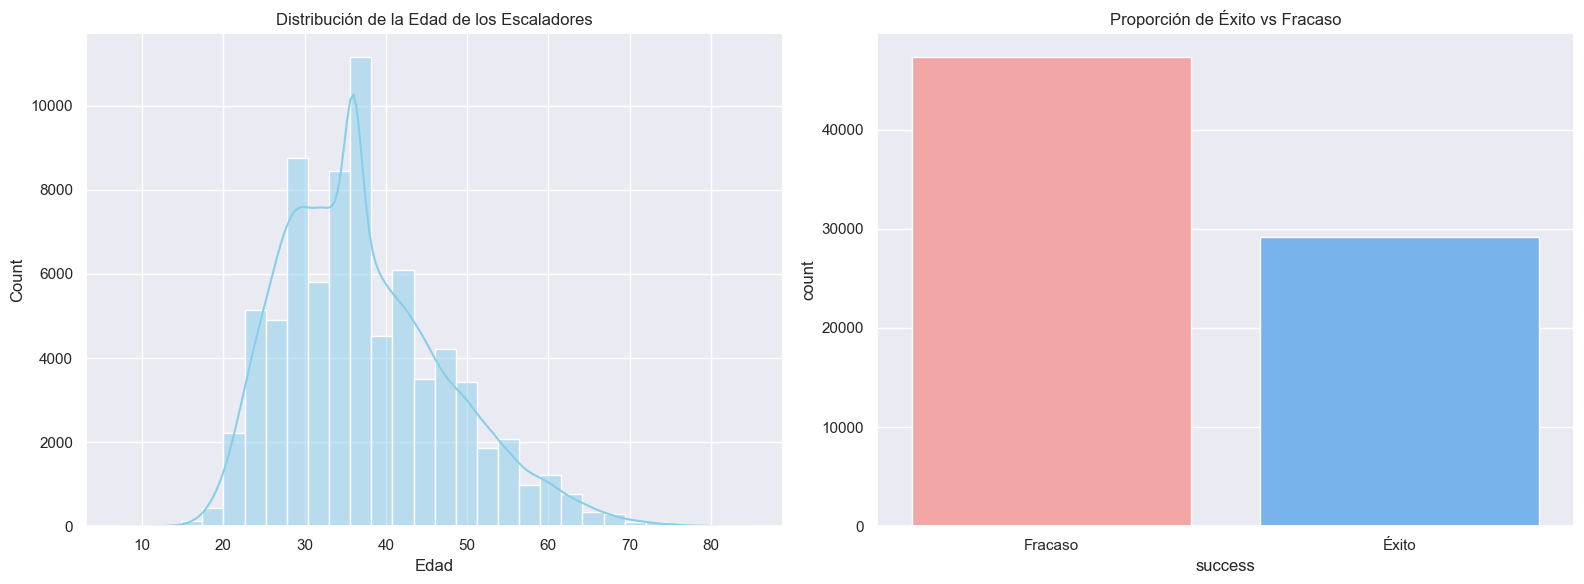

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución de Edad
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de la Edad de los Escaladores')
axes[0].set_xlabel('Edad')

# Éxitos vs Fracasos
sns.countplot(data=df, x='success', ax=axes[1], palette=['#ff9999','#66b3ff'])
axes[1].set_title('Proporción de Éxito vs Fracaso')
axes[1].set_xticklabels(['Fracaso', 'Éxito'])

plt.tight_layout()
plt.show()

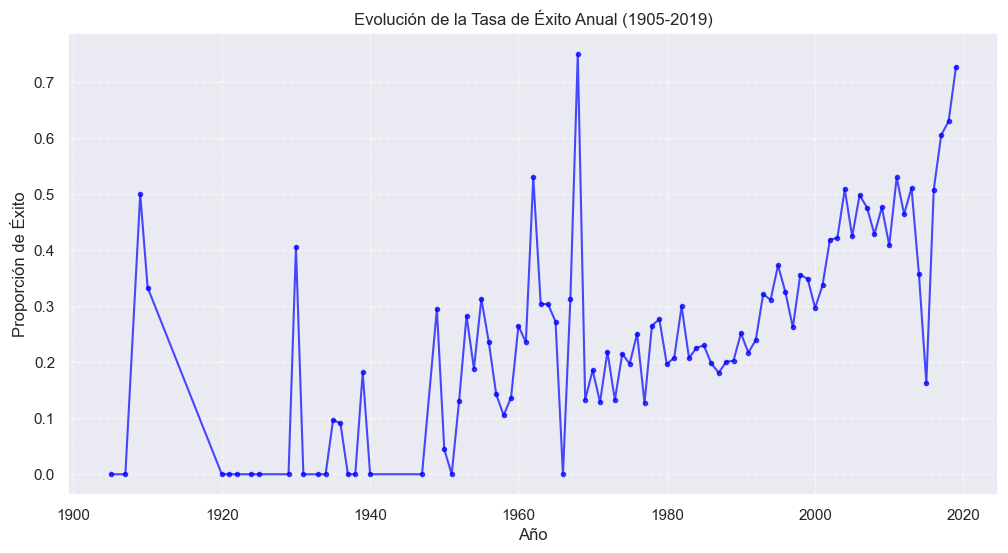

In [17]:
# Evolución de la Tasa de Éxito por Año
plt.figure(figsize=(12, 6))
df.groupby('year')['success'].mean().plot(kind='line', color='blue', marker='.', alpha=0.7)
plt.title('Evolución de la Tasa de Éxito Anual (1905-2019)')
plt.xlabel('Año')
plt.ylabel('Proporción de Éxito')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

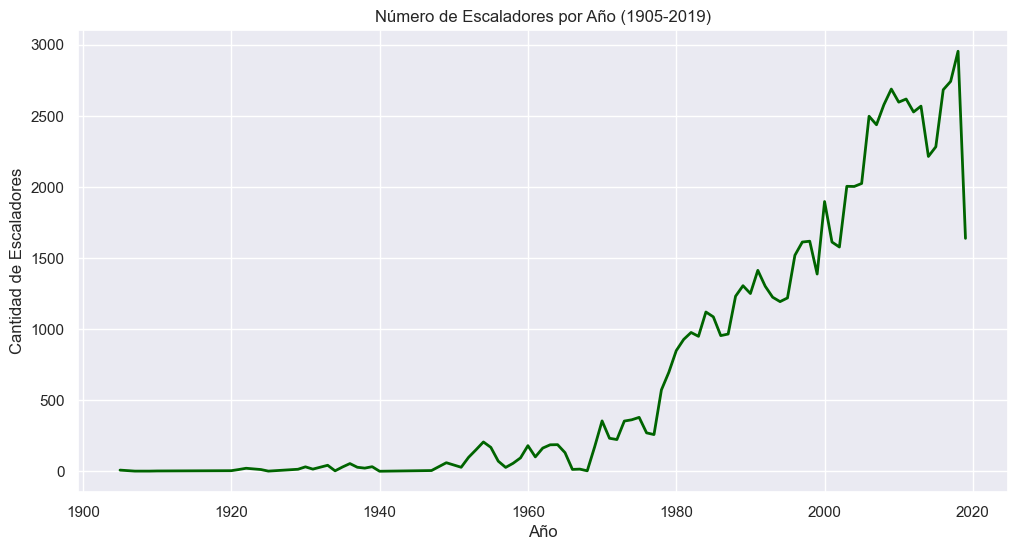

In [18]:
# Evolución temporal de las expediciones
plt.figure(figsize=(12, 6))
df['year'].value_counts().sort_index().plot(kind='line', color='darkgreen', linewidth=2)
plt.title('Número de Escaladores por Año (1905-2019)')
plt.xlabel('Año')
plt.ylabel('Cantidad de Escaladores')
plt.show()

### Análisis Bivariado: Factores que afectan el Éxito
¿Cómo influyen el género, el oxígeno y el rol en la tasa de éxito?

C:\Users\Arnold's\AppData\Local\Temp\ipykernel_16224\3184641993.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sex', y='success', ax=axes[0], palette='muted')
C:\Users\Arnold's\AppData\Local\Temp\ipykernel_16224\3184641993.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='oxygen_used', y='success', ax=axes[1], palette='plasma')
C:\Users\Arnold's\AppData\Local\Temp\ipykernel_16224\3184641993.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Sin Oxígeno', 'Con Oxígeno'])
C:\Users\Arnold's\AppData\Local\Temp\ipykernel_16224\3184641993.py:14: FutureWar

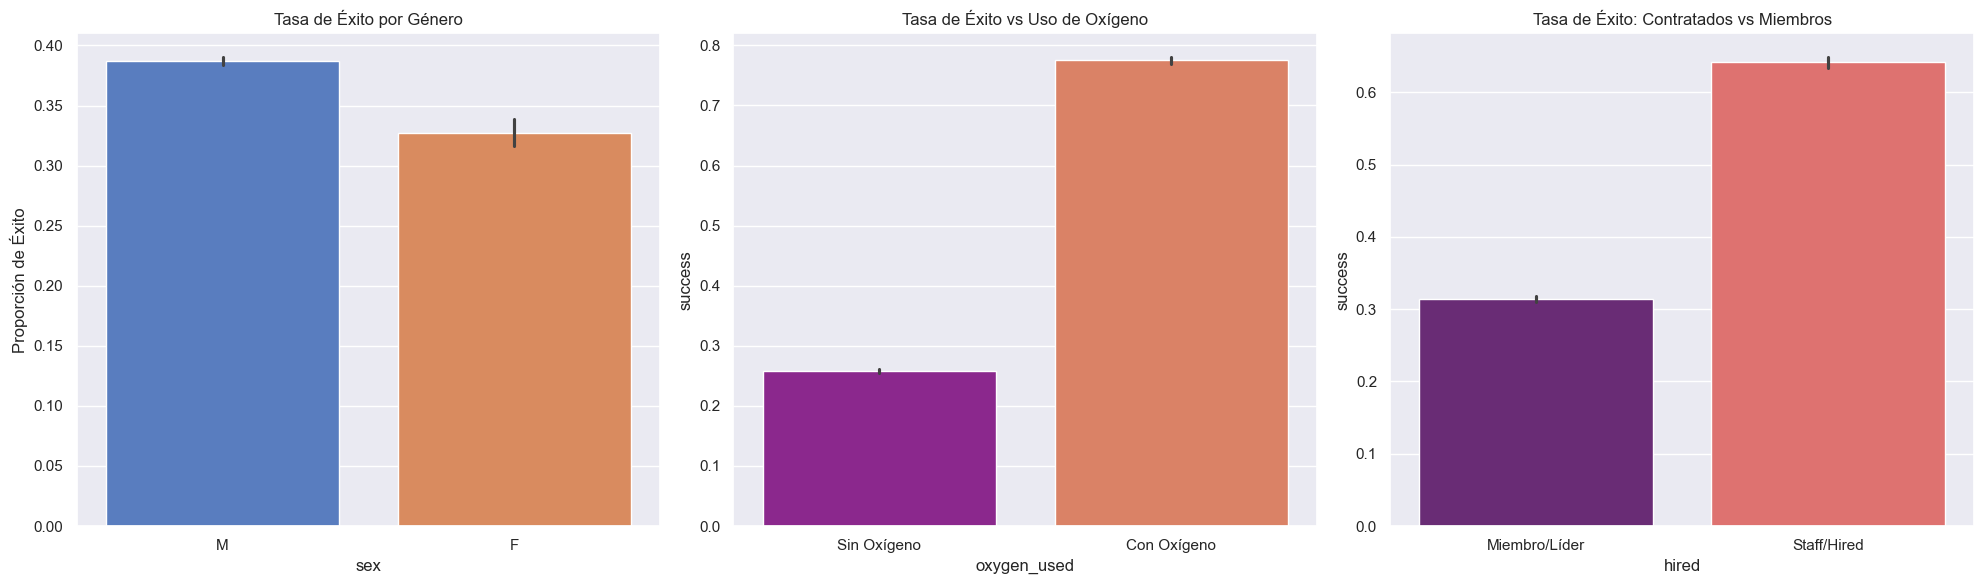

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Éxito por Género
sns.barplot(data=df, x='sex', y='success', ax=axes[0], palette='muted')
axes[0].set_title('Tasa de Éxito por Género')
axes[0].set_ylabel('Proporción de Éxito')

# Éxito por Oxígeno
sns.barplot(data=df, x='oxygen_used', y='success', ax=axes[1], palette='plasma')
axes[1].set_title('Tasa de Éxito vs Uso de Oxígeno')
axes[1].set_xticklabels(['Sin Oxígeno', 'Con Oxígeno'])

# Éxito por Rol Hired (Scherpas/Staff vs Clientes)
sns.barplot(data=df, x='hired', y='success', ax=axes[2], palette='magma')
axes[2].set_title('Tasa de Éxito: Contratados vs Miembros')
axes[2].set_xticklabels(['Miembro/Líder', 'Staff/Hired'])

plt.tight_layout()
plt.show()

### Análisis Multivariado: Edad, Sexo y Éxito
Validamos cómo interactúan estas tres variables. Agrupamos la edad en décadas para suavizar la visualización.

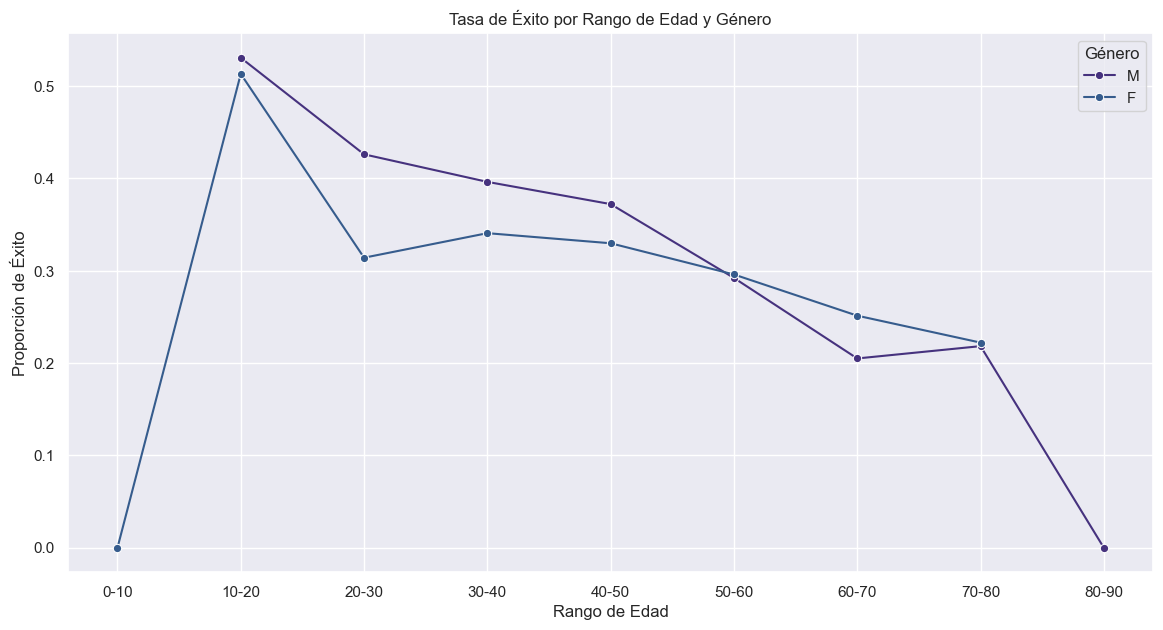

In [20]:
# Crear rangos de edad (bins)
df['age_range'] = pd.cut(df['age'], bins=range(0, 100, 10), labels=[f'{i}-{i+10}' for i in range(0, 90, 10)])

plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='age_range', y='success', hue='sex', marker='o', errorbar=None)
plt.title('Tasa de Éxito por Rango de Edad y Género')
plt.xlabel('Rango de Edad')
plt.ylabel('Proporción de Éxito')
plt.legend(title='Género')
plt.show()

**Análisis de Validación:**
*   **Juventud y Éxito**: Se observa que los escaladores más jóvenes (10-20 años) tienen tasas de éxito excepcionalmente altas (>50%), lo que sugiere una selección y preparación muy rigurosa en este grupo.
*   **Declive con la Edad**: Existe una tendencia clara de disminución del éxito conforme aumenta la edad a partir de la tercera década de vida.
*   **Equidad en la Tercera Edad**: Mientras que en edades medias los hombres muestran una ligera ventaja en la tasa de éxito, en escaladores de más de 50-60 años las tasas tienden a igualarse entre géneros.

### Análisis Profundo de Riesgo y Seguridad
A continuación, desglosamos la mortalidad por diferentes factores para entender dónde reside el verdadero peligro.

In [21]:
# 1. Tasa por Éxito vs Fracaso
success_death = df.groupby('success')['died'].mean() * 100
print("--- Tasa de Mortalidad (%) ---")
print(f"En intentos fallidos: {success_death[0]:.2f}%")
print(f"Tras alcanzar la cumbre: {success_death[1]:.2f}%")

# 2. Tasa por Rol (Hired vs Member)
hired_death = df.groupby('hired')['died'].mean() * 100
print("\n--- Riesgo por Rol ---")
print(f"Miembros/Líderes: {hired_death[0]:.2f}%")
print(f"Personal contratado (Sherpas/Staff): {hired_death[1]:.2f}%")

--- Tasa de Mortalidad (%) ---
En intentos fallidos: 1.83%
Tras alcanzar la cumbre: 0.82%

--- Riesgo por Rol ---
Miembros/Líderes: 1.30%
Personal contratado (Sherpas/Staff): 2.02%


### Visualización de Riesgo por Pico
Analizamos los picos más peligrosos (con más de 100 registros).

C:\Users\Arnold's\AppData\Local\Temp\ipykernel_16224\4240619445.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=deadly_picks['rate'], y=deadly_picks.index, palette='Reds_r')


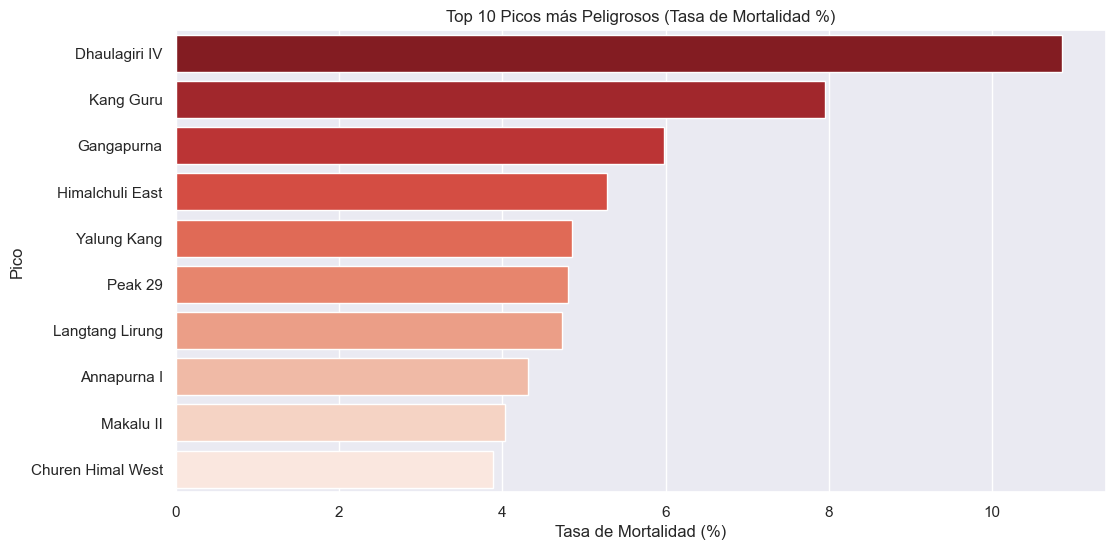

In [22]:
peak_stats = df.groupby('peak_name')['died'].agg(['sum', 'count'])
peak_stats['rate'] = (peak_stats['sum'] / peak_stats['count']) * 100
deadly_picks = peak_stats[peak_stats['count'] > 100].sort_values('rate', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=deadly_picks['rate'], y=deadly_picks.index, palette='Reds_r')
plt.title('Top 10 Picos más Peligrosos (Tasa de Mortalidad %)')
plt.xlabel('Tasa de Mortalidad (%)')
plt.ylabel('Pico')
plt.show()

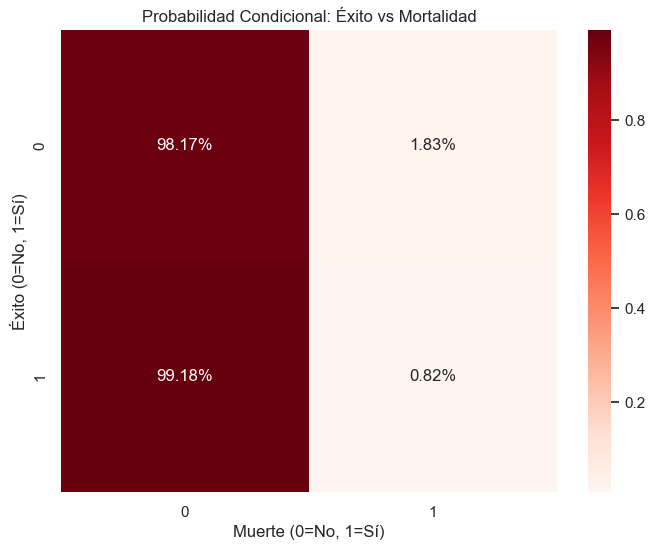

In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(pd.crosstab(df['success'], df['died'], normalize='index'), 
            annot=True, cmap='Reds', fmt='.2%')
plt.title('Probabilidad Condicional: Éxito vs Mortalidad')
plt.ylabel('Éxito (0=No, 1=Sí)')
plt.xlabel('Muerte (0=No, 1=Sí)')
plt.show()

### Matriz de Correlación
Finalizamos viendo cómo se relacionan todas las variables numéricas.

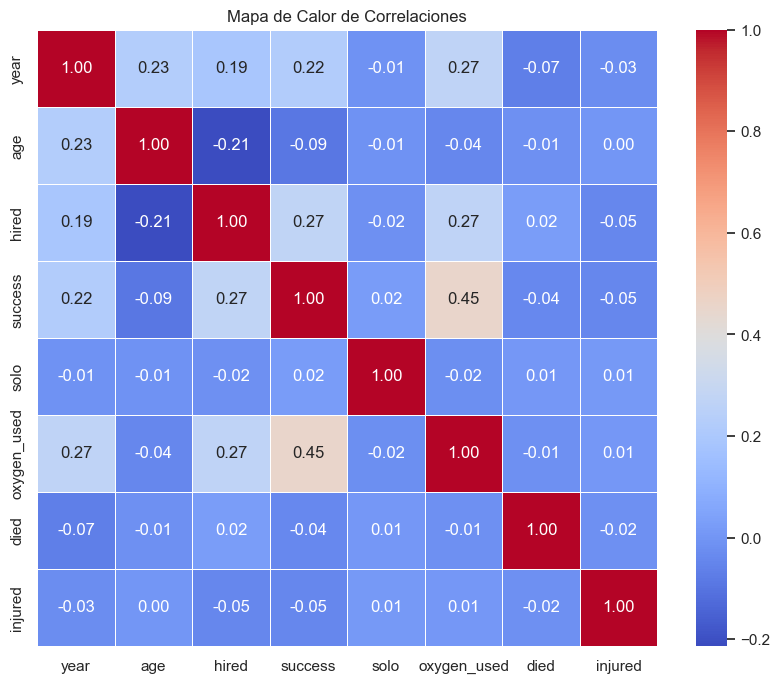

In [24]:
# Seleccionar variables relevantes
corr_df = df[['year', 'age', 'hired', 'success', 'solo', 'oxygen_used', 'died', 'injured']]
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

**Interpretación de Correlaciones Clave:**
*   **Oxígeno (0.44)**: Es el factor individual con mayor impacto positivo en el éxito.
*   **Hired (0.28)**: El personal de apoyo (Sherpas y guías) tiene una ventaja competitiva clara debido a su experiencia y rol.
*   **Año (0.15)**: Existe una mejora progresiva en las tasas de éxito con el paso de las décadas, probablemente por mejores equipos, pronósticos climáticos y logística.
*   **Edad (-0.07)**: Aunque leve, hay una tendencia inversa; a mayor edad, la probabilidad de éxito tiende a disminuir.
*   **Muerte (-0.05)**: Correlación negativa con el éxito, confirmando que el riesgo de muerte es ligeramente superior en los intentos que fracasan.

### Nota sobre Trazabilidad de Miembros
Es importante notar que el `member_id` es único por expedición, no por persona. Esto impide rastrear la carrera completa de un escalador sin datos adicionales (como nombres). Sin embargo, para predicción por intento, las variables contextuales aquí analizadas son las más robustas.

### Conclusiones Principales
1. **Oxígeno**: Es el factor con mayor correlación visual respecto al éxito.
2. **Hired**: El personal contratado (Scherpas, guías) tiene una tasa de éxito significativamente mayor, pero asume casi el doble de riesgo de mortalidad (2.02% vs 1.30%).
3. **Mortalidad Post-Cumbre**: Alcanzar la cima no garantiza seguridad; existe un 0.82% de probabilidad de muerte tras el éxito, principalmente en el descenso.
4. **Picos de Riesgo**: Montañas como el Dhaulagiri IV presentan riesgos extremos (>10% de mortalidad) comparados con el promedio general del 1.45%.